# Wilds datasets

This notebook contain analysis of the WILDS datasets. Wilds is the collection of datasets with distribution shift in them from various areas (computer vision, tabular data, text data). \
link: https://wilds.stanford.edu/ \
paper: https://arxiv.org/pdf/2012.07421 \
github: https://github.com/p-lambda/wilds/

The idea is to use these datasets with natural data shifts in them in our experiments, to create data streams with more realistic data drifts that could occur in the real life. Each dataset contains metadata, that could be used to determine the sircumstances in wich given learning example was obtained. We can use this information to split the data into several domains, use those as different concepts during training.

In [1]:
import torchvision.transforms as transforms

from wilds import get_dataset
from wilds.common.data_loaders import get_train_loader

/home/jedrzejkozal/anaconda3/envs/cl-concept-drift/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## iWilds dataset

This dataset contains the images of animals in the wild, taken by camera traps. Each image is labeled by the type of animal present in this image. We also have access to metadata that include camera trap id, sequence id, and  the timestamp. Based on this information we can split data into several tasks (based on classes) and also introduce data drifts that are more realistic than those created by adding noise to images.

In [2]:
# Load the full dataset, and download it if necessary
dataset = get_dataset(dataset="iwildcam", download=True)
print(dataset)
print(type(dataset))
print('dataset size = ', len(dataset))

<class 'wilds.datasets.iwildcam_dataset.IWildCamDataset'>
dataset size =  203029


In [4]:
# Get the training set
train_data = dataset.get_subset(
    "train",
    transform=transforms.Compose(
        [transforms.Resize((448, 448)), transforms.ToTensor()]
    ),
)
print('train set size: ', len(train_data))

train set size:  129809


##### Few sample images

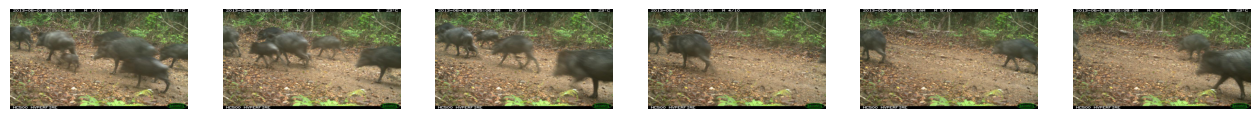

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

n_images = 6
for i in range(n_images):
    img, _, _ = dataset[i]
    plt.subplot(1, n_images, i+1)
    plt.imshow(img)
    plt.axis('off')

The images are grouped in sequences. Once the motion detector in camera trap is triggered, the sequence of photos is taken. Each sequnce in given trap has its own id:

In [16]:
for i in range(10):
    _, _, metadata = dataset[i]
    print(f'trap id = {metadata[0]}, sequence id = {metadata[1]}')

trap id = 2, sequence id = 2124
trap id = 2, sequence id = 2124
trap id = 2, sequence id = 2124
trap id = 2, sequence id = 2124
trap id = 2, sequence id = 2124
trap id = 2, sequence id = 2125
trap id = 2, sequence id = 2125
trap id = 2, sequence id = 2125
trap id = 2, sequence id = 2125
trap id = 2, sequence id = 2125


##### What is the average sequnce length?

number of unique sequnces =  36484


Text(0, 0.5, 'count')

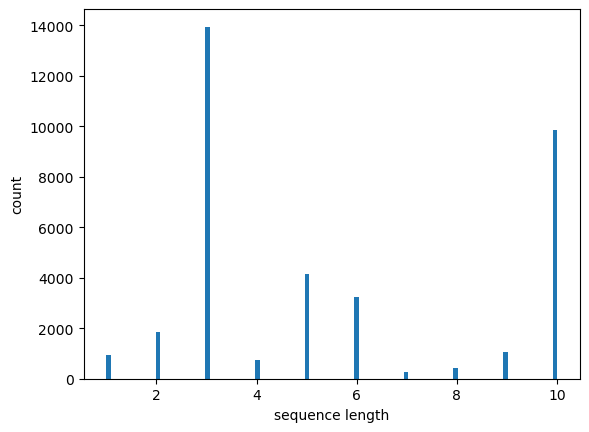

In [69]:
import numpy as np

trap_ids = list()
for i in range(len(dataset)):
    _, _, metadata = dataset[i]
    unique_id = f'{metadata[0]}_{metadata[1]}'
    trap_ids.append(unique_id)
    # if i > 10:
    #     break

print('number of unique sequnces = ', len(set(trap_ids)))
_, sequence_lens = np.unique(trap_ids, return_counts=True)

plt.hist(sequence_lens, bins=100)
plt.xlabel('sequence length')
plt.ylabel('count')

In [28]:
print('min sequnce len = ', min(sequence_lens))
print('max sequence len = ', max(sequence_lens))
print('mean sequence len = ', sum(sequence_lens) / len(sequence_lens))

min sequnce len =  1
max sequence len =  10
mean sequence len =  5.5648777546321675


##### How does images from different sequences look like?

showing img id 1 trap id 2 sequence id 2124
showing img id 6 trap id 2 sequence id 2125
showing img id 11 trap id 2 sequence id 2126
showing img id 16 trap id 2 sequence id 2127
showing img id 21 trap id 2 sequence id 2128
showing img id 26 trap id 2 sequence id 2129
showing img id 31 trap id 2 sequence id 2130
showing img id 41 trap id 2 sequence id 2131
showing img id 46 trap id 2 sequence id 2132
showing img id 51 trap id 2 sequence id 2157
showing img id 61 trap id 2 sequence id 2158
showing img id 71 trap id 2 sequence id 2159
showing img id 81 trap id 2 sequence id 2228
showing img id 91 trap id 2 sequence id 2229
showing img id 101 trap id 2 sequence id 2302
showing img id 111 trap id 2 sequence id 14834
showing img id 116 trap id 2 sequence id 14920
showing img id 121 trap id 2 sequence id 15377
showing img id 126 trap id 2 sequence id 15693
showing img id 131 trap id 2 sequence id 16090
showing img id 136 trap id 2 sequence id 16870
showing img id 141 trap id 2 sequence id 168

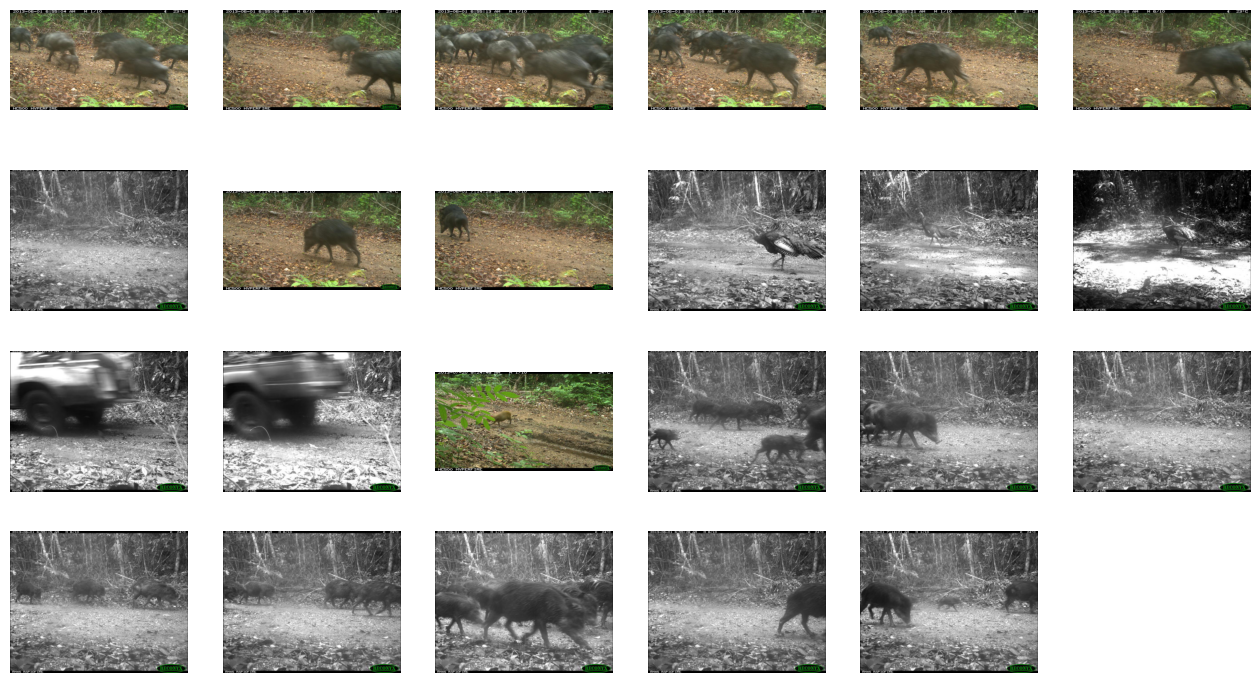

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 9))

i = 0
seen_sequences = set()
camera_trap_id = dataset[0][2][0].item()
images = list()

while True:
    img, _, metadata = dataset[i]
    i += 1

    if metadata[0].item() != camera_trap_id:
        break

    sequence_id = metadata[1].item()
    if sequence_id not in seen_sequences:
        print(
            f'showing img id {i} trap id {metadata[0].item()} sequence id {sequence_id}')
        seen_sequences.add(sequence_id)
        images.append(img)


for i, img in enumerate(images):
    plt.subplot(len(images) // 6 + 1, 6, i+1)
    plt.imshow(img)
    plt.axis('off')

##### How does images from different traps look like?

showing img id 1 trap id 2
showing img id 151 trap id 6
showing img id 181 trap id 8
showing img id 238 trap id 13
showing img id 546 trap id 15
showing img id 549 trap id 16
showing img id 555 trap id 17
showing img id 560 trap id 18
showing img id 569 trap id 19
showing img id 572 trap id 20
showing img id 585 trap id 23
showing img id 846 trap id 26
showing img id 1176 trap id 28
showing img id 1179 trap id 31
showing img id 1226 trap id 32
showing img id 1229 trap id 33
showing img id 1340 trap id 34
showing img id 1390 trap id 35


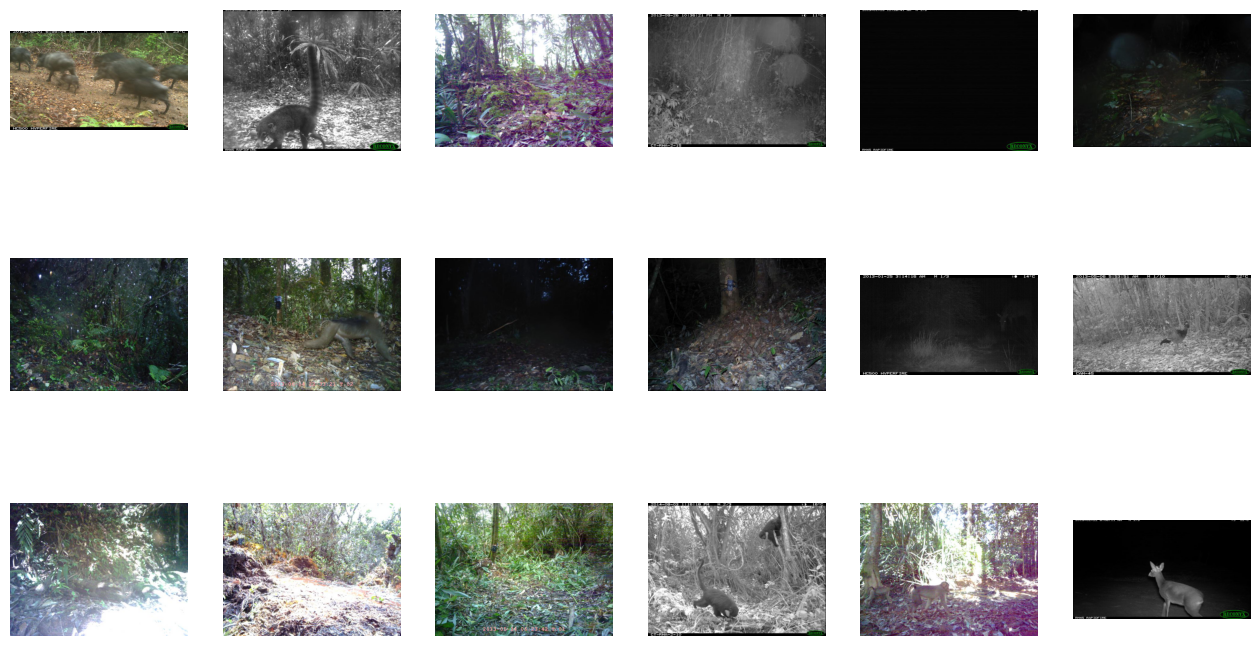

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 9))

i = 0
seen_traps = set()
images = list()

while len(images) < 18:
    img, _, metadata = dataset[i]
    i += 1

    trap_id = metadata[0].item()
    if trap_id not in seen_traps:
        print(f'showing img id {i} trap id {trap_id}')
        seen_traps.add(trap_id)
        images.append(img)


for i, img in enumerate(images):
    plt.subplot(3, 6, i+1)
    plt.imshow(img)
    plt.axis('off')

##### What is the number of traps?

number of unique traps =  203029


Text(0.5, 1.0, 'number of images per trap')

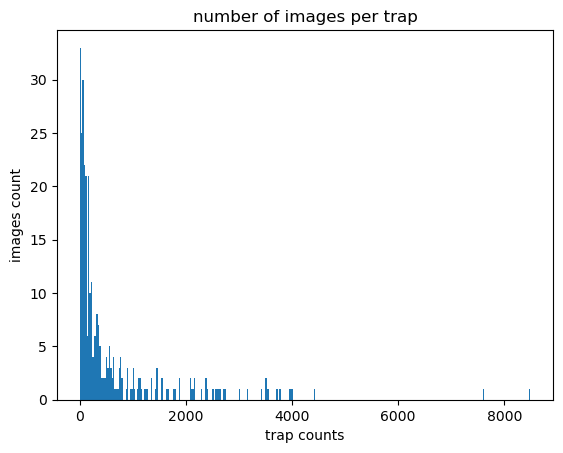

In [70]:
import numpy as np

trap_ids = list()
for i in range(len(dataset)):
    _, _, metadata = dataset[i]
    trap_id = metadata[0]
    trap_ids.append(trap_id)
    # if i > 10:
    #     break

print('number of unique traps = ', len(set(trap_ids)))
_, trap_counts = np.unique(trap_ids, return_counts=True)

plt.hist(trap_counts, bins=len(trap_counts))
plt.xlabel('trap counts')
plt.ylabel('images count')
plt.title('number of images per trap')

In [57]:
print('min trap images count = ', min(trap_counts))
print('max trap images count = ', max(trap_counts))
print('mean trap images count = ', sum(trap_counts) / len(trap_counts))

min trap images count =  1
max trap images count =  8494
mean trap images count =  628.5727554179566


##### How many classes are in the dataset?

number of classes =  182


Text(0, 0.5, 'images count')

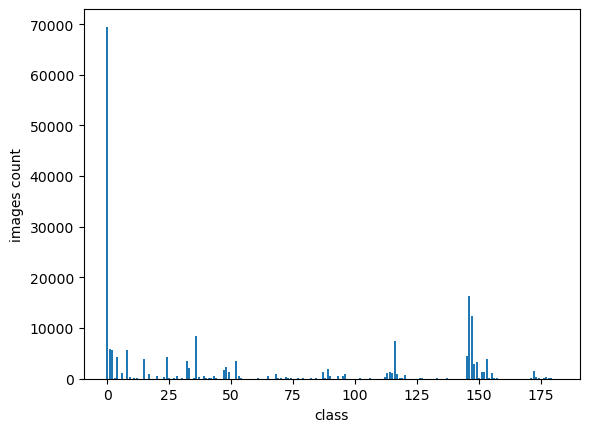

In [71]:
labels = list()

for _, label, _ in dataset:
    label = label.item()
    labels.append(label)

unique_classes, class_counts = np.unique(labels, return_counts=True)
print('number of classes = ', len(unique_classes))

x = list(range(len(unique_classes)))
plt.bar(x, class_counts)
plt.xlabel('class')
plt.ylabel('images count')

same plot, with outlier removed:

Text(0, 0.5, 'images count')

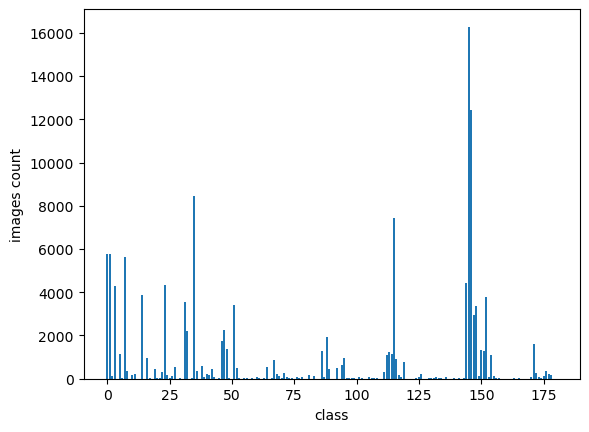

In [74]:
x = list(range(len(unique_classes)-1))
plt.bar(x, class_counts[1:])
plt.xlabel('class')
plt.ylabel('images count')

Text(0.5, 1.0, 'number of classes with given amount of images')

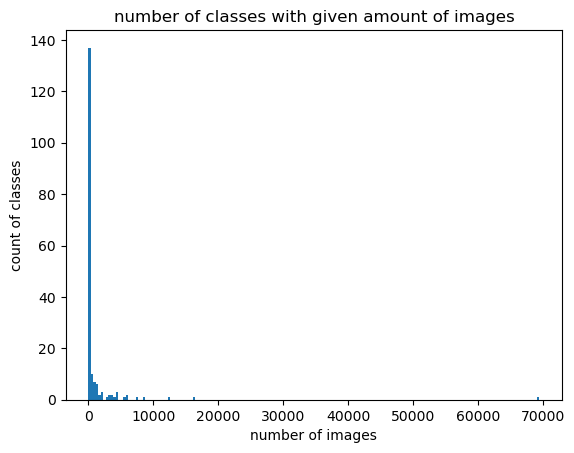

In [72]:
plt.hist(class_counts, bins=len(unique_classes))
plt.xlabel('number of images')
plt.ylabel('count of classes')
plt.title('number of classes with given amount of images')

The dataset is imballanced. We should take this into consideration when performing evalution and choosing metrics.

There are few classes, that have high amount of learning examples. Most of classes have small amount of images. If the class does not have images taken from at least two camera traps, than we cannot use it for concept drift.

##### How many classes can be used for at least 1 concept drift?

How many classes are in the dataset that have at least two different camera trap id?

In [75]:
import collections

class_traps_ids = collections.defaultdict(set)

for _, label, metadata in dataset:
    label = label.item()
    trap_id = metadata[0].item()
    class_traps_ids[label].add(trap_id)

In [77]:
at_least_2_domains = [label for label in class_traps_ids if len(class_traps_ids[label]) > 1]
print('class count with at least 2 different camera traps =', len(at_least_2_domains))

class count with at least 2 different camera traps = 137


what will happen if we filter out the classes with less than 5 images?

In [78]:
rare_classes = [label for label, count in zip(unique_classes, class_counts) if count <= 5]
rare_classes = set(rare_classes)

at_least_2_domains = [label for label in class_traps_ids if len(class_traps_ids[label]) > 1 and label not in rare_classes]
print('class count with at least 2 different camera traps =', len(at_least_2_domains))

class count with at least 2 different camera traps = 132


In [79]:
rare_classes = [label for label, count in zip(unique_classes, class_counts) if count <= 5]
rare_classes = set(rare_classes)

at_least_2_domains = [label for label in class_traps_ids if len(class_traps_ids[label]) > 2 and label not in rare_classes]
print('class count with at least 3 different camera traps =', len(at_least_2_domains))

class count with at least 3 different camera traps = 110


In [81]:
rare_classes = [label for label, count in zip(unique_classes, class_counts) if count <= 500]
rare_classes = set(rare_classes)

at_least_2_domains = [label for label in class_traps_ids if len(class_traps_ids[label]) > 2 and label not in rare_classes]
print('class count with at least 3 different camera traps =', len(at_least_2_domains))

class count with at least 3 different camera traps = 42


We have 42 classes with at least 500 samples, that have been captured at at least 2 camera traps. Maybe we can work with that.